In [47]:
# NBA Kalshi series stems suited to the RN-JD spec (continuous in-game underlying).
# Generated using Claude Opus 4.8 from list of all NBA series.
HIGH_FIT = [
    # full-game team markets
    "KXNBAGAME", "KXNBASPREAD", "KXNBATOTAL", "KXNBATEAMTOTAL", "KXNBAUPSET",
    # halves
    "KXNBA1HWINNER", "KXNBA1HSPREAD", "KXNBA1HTOTAL",
    "KXNBA2HWINNER", "KXNBA2HSPREAD", "KXNBA2HTOTAL",
    # quarters
    "KXNBA1QWINNER", "KXNBA1QSPREAD", "KXNBA1QTOTAL",
    "KXNBA2QWINNER", "KXNBA2QSPREAD", "KXNBA2QTOTAL",
    "KXNBA3QWINNER", "KXNBA3QSPREAD", "KXNBA3QTOTAL",
    "KXNBA4QWINNER", "KXNBA4QSPREAD", "KXNBA4QTOTAL",
    # single-game player props (BLK/STL/FTM/3PT are jump-dominated -> watch the var gate)
    "KXNBAPTS", "KXNBAREB", "KXNBAAST", "KXNBA3PT", "KXNBAFTM", "KXNBABLK", "KXNBASTL",
    # prop combos
    "KXNBAPR", "KXNBAPA", "KXNBARA", "KXNBAPRA",
    # head-to-head
    "KXNBAH2HPTS", "KXNBAH2H3PT", "KXNBAH2HPRA", "KXNBAH2HBENCHPTS", "KXNBAH2HTEAM3PT",
]

# Discrete game-by-game walk or longer horizon -> separate model track, not the same spec.
MEDIUM_FIT = [
    # series aggregates (accumulate in per-game chunks)
    "KXNBASERIESPTS", "KXNBASERIESTOTALPTS", "KXNBASERIESSPREAD",
    "KXNBASERIESPTSSPREAD", "KXNBASERIESSCORE", "KXNBASERIESGAMES", "KXNBAGAMES",
    # series winner / flags
    "KXNBASERIES", "KXNBAGAME7", "KXNBASWEEP", "KXNBASERIESROADWIN",
    "KXNBASERIESROADWINS", "KXNBASERIESOT", "KXNBASERIESCOMEBACK", "KXNBASERIESGCOMEBACK",
    # series stat leaders
    "KXNBASERIESPTSLEADER", "KXNBASERIESREBLEADER",
    "KXNBASERIESASTLEADER", "KXNBASERIES3PMLEADER",
    # same-slate composites / parlays
    "KXNBAPTSALLGAMES", "KXNBA3PTALLGAMES", "KXNBAPREPACK2ML", "KXNBAPREPACK3ML",
    # single-game, back-loaded or tail
    "KXNBAOVERTIME", "KXNBA30COMEBACK",
    # playoff scoring over a long window
    "KXNBAPLAYOFFPTS", "KXNBAPLAYOFF3D",
]

In [48]:
import json
from collections import Counter

with open("nba_markets.json", "r") as f:
    nba_markets = json.load(f)
high_fit_markets = [m for m in nba_markets if m["event_ticker"].split("-")[0] in HIGH_FIT]
print(f"Found {len(high_fit_markets)} high-fit markets")
high_fit_counts = Counter(m["event_ticker"].split("-")[0] for m in high_fit_markets)
for series, count in sorted(high_fit_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{series}: {count}")


Found 150998 high-fit markets
KXNBAPTS: 23504
KXNBAREB: 22611
KXNBAAST: 17715
KXNBASPREAD: 16889
KXNBA3PT: 16559
KXNBATOTAL: 14766
KXNBATEAMTOTAL: 9468
KXNBASTL: 6894
KXNBA1HSPREAD: 5807
KXNBA1HTOTAL: 4698
KXNBABLK: 3929
KXNBAGAME: 2896
KXNBA1HWINNER: 1566
KXNBA2HWINNER: 1566
KXNBA2HSPREAD: 865
KXNBA2HTOTAL: 738
KXNBA1QTOTAL: 64
KXNBA2QTOTAL: 64
KXNBA3QTOTAL: 64
KXNBA4QTOTAL: 64
KXNBAFTM: 53
KXNBA1QSPREAD: 32
KXNBA2QSPREAD: 32
KXNBA3QSPREAD: 32
KXNBA4QSPREAD: 32
KXNBAH2HBENCHPTS: 16
KXNBA1QWINNER: 12
KXNBA2QWINNER: 12
KXNBA3QWINNER: 12
KXNBA4QWINNER: 12
KXNBAH2HPRA: 8
KXNBAUPSET: 8
KXNBAH2H3PT: 6
KXNBAH2HPTS: 2
KXNBAH2HTEAM3PT: 2


In [49]:
with open("nba_markets.json", "r") as f:
    markets = json.load(f)
medium_fit_markets = [m for m in markets if m["event_ticker"].split("-")[0] in MEDIUM_FIT]
medium_fit_counts = Counter(m["event_ticker"].split("-")[0] for m in medium_fit_markets)
print(f"Found {len(medium_fit_markets)} medium-fit markets")
for series, count in medium_fit_counts.items():
    print(f"{series}: {count}")

Found 760 medium-fit markets
KXNBA30COMEBACK: 1
KXNBA3PTALLGAMES: 17
KXNBAGAME7: 7
KXNBAOVERTIME: 86
KXNBAPLAYOFF3D: 28
KXNBAPLAYOFFPTS: 54
KXNBAPREPACK2ML: 36
KXNBAPREPACK3ML: 24
KXNBAPTSALLGAMES: 12
KXNBASERIES: 48
KXNBASERIES3PMLEADER: 1
KXNBASERIESGAMES: 43
KXNBASERIESGCOMEBACK: 3
KXNBASERIESPTS: 3
KXNBASERIESPTSLEADER: 91
KXNBASERIESROADWIN: 105
KXNBASERIESROADWINS: 3
KXNBASERIESSCORE: 116
KXNBASERIESSPREAD: 74
KXNBASWEEP: 8


# Start with KXNBAGAME event ticker
    - [x] verify that it represents contracts on individual game winner
    - [x] identify important fields on this contract
    - [ ] parse full Market object from Kalshi into set of useful metadata

In [84]:
import random

kxnbagame_markets = [m for m in markets if m["event_ticker"].split("-")[0] == "KXNBAGAME"]
print(f"Found {len(kxnbagame_markets)} KXNBAGAME markets")

sample_kxnbagame_markets = random.sample(kxnbagame_markets, 10)
for m in sample_kxnbagame_markets:
    print(m["rules_primary"])

Found 2896 KXNBAGAME markets
If Phoenix wins the Golden State at Phoenix professional basketball game originally scheduled for Apr 17, 2026, then the market resolves to Yes.
If Orlando wins the Charlotte at Orlando professional basketball game originally scheduled for Apr 17, 2026, then the market resolves to Yes.
If Indiana wins the Philadelphia at Indiana professional basketball game originally scheduled for Feb 24, 2026, then the market resolves to Yes.
If Cleveland wins the Cleveland at Atlanta professional basketball game originally scheduled for Apr 10, 2026, then the market resolves to Yes.
If Portland wins the Portland at San Antonio professional basketball game originally scheduled for Apr 8, 2026, then the market resolves to Yes.
If Chicago wins the Chicago at New York professional basketball game originally scheduled for Apr 3, 2026, then the market resolves to Yes.
If Cleveland wins the Game 3: New York at Cleveland professional basketball game originally scheduled for May 

In [85]:
from pprint import pprint
pprint(kxnbagame_markets[-1])

{'can_close_early': True,
 'close_time': '2025-04-16T02:39:09.736516Z',
 'created_time': '2025-04-14T17:51:49.019458Z',
 'custom_strike': {'basketball_team': 'e0729403-9c95-4ee2-b5d4-f704d8322570'},
 'early_close_condition': 'This market will close and expire after a winner is '
                          'declared.',
 'event_ticker': 'KXNBAGAME-25APR15ATLORL',
 'expected_expiration_time': '2025-04-16T02:30:00Z',
 'expiration_time': '2027-04-15T23:30:00Z',
 'expiration_value': 'Orlando',
 'fractional_trading_enabled': True,
 'last_price_dollars': '0.0100',
 'latest_expiration_time': '2027-04-15T23:30:00Z',
 'liquidity_dollars': '0.0000',
 'market_type': 'binary',
 'no_ask_dollars': '1.0000',
 'no_bid_dollars': '0.9900',
 'no_sub_title': 'Atlanta',
 'notional_value_dollars': '1.0000',
 'open_interest_fp': '0.00',
 'open_time': '2025-04-14T18:00:00Z',
 'previous_price_dollars': '0.0100',
 'previous_yes_ask_dollars': '0.0100',
 'previous_yes_bid_dollars': '0.0000',
 'price_level_structure'

- Extract following info from ticker:
    - teams
    - yes/no winner
- Copy
    - settlement_ts from settlement_ts
    - title from title
    - result from result
    - volume from volume_fp
    - estimated_expiration_ts form expected_expiration_time
    - expiration_ts from expiration_time
    - open_ts from open_time

In [69]:
TICKER_TO_TEAM_MAP = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BKN": "Brooklyn Nets",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DET": "Detroit Pistons",
    "IND": "Indiana Pacers",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "NYK": "New York Knicks",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "TOR": "Toronto Raptors",
    "WAS": "Washington Wizards",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "LAC": "LA Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIN": "Minnesota Timberwolves",
    "NOP": "New Orleans Pelicans",
    "OKC": "Oklahoma City Thunder",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "UTA": "Utah Jazz",
    "GUA": "Guangzhou Loong-Lions"
}

In [ ]:
from dataclasses import dataclass
from datetime import date, datetime, timedelta
from typing import List, Dict

@dataclass
class GameWinnerMarketMetadata:
    ticker: str
    title: str
    rules_primary: str
    event_ticker: str
    result: ["yes", "no"]
    volume: float
    open_ts: datetime
    settlement_ts: datetime
    expected_expiration_time: datetime
    expiration_ts: datetime
    teams: List[str]
    yes_winner: str
    no_winner: str

def parse_markets(markets: List[Dict]) -> List[GameWinnerMarketMetadata]:
    parsed_markets = []
    for market in markets:

        ticker = market["ticker"]
        teams = [TICKER_TO_TEAM_MAP[ticker[-10:-7]], TICKER_TO_TEAM_MAP[ticker[-7:-4]]]
        yes_winner = TICKER_TO_TEAM_MAP[ticker[-3:]]
        no_winner = teams[0] if yes_winner == teams[1] else teams[1]

        if market["result"] == "scalar":
            print(f"{ticker}: scalar result, game was postponed/canceled")
            continue

        parsed_markets.append(GameWinnerMarketMetadata(
            title=market["title"],
            rules_primary=market["rules_primary"],
            ticker=ticker,
            event_ticker=market["event_ticker"],
            result=market["result"],
            volume=float(market["volume_fp"]),
            open_ts=datetime.fromisoformat(market["open_time"]),
            settlement_ts=datetime.fromisoformat(market["settlement_ts"]),
            expected_expiration_time=datetime.fromisoformat(market["expected_expiration_time"]),
            expiration_ts=datetime.fromisoformat(market["expiration_time"]),
            teams=teams,
            yes_winner=yes_winner,
            no_winner=no_winner
        ))
    return parsed_markets

market_metadata = parse_markets(kxnbagame_markets)

KXNBAGAME-26JAN25DALMIL-MIL: scalar result, game was postponed/canceled
KXNBAGAME-26JAN25DALMIL-DAL: scalar result, game was postponed/canceled
KXNBAGAME-26JAN25DENMEM-MEM: scalar result, game was postponed/canceled
KXNBAGAME-26JAN25DENMEM-DEN: scalar result, game was postponed/canceled
KXNBAGAME-26JAN08MIACHI-MIA: scalar result, game was postponed/canceled
KXNBAGAME-26JAN08MIACHI-CHI: scalar result, game was postponed/canceled


- some markets have 'scalar' results
    - these are due to indefinitely postponed/canceled games
    - kalshi resolves to a 50/50 payout
    - we ignore and remove these

In [108]:
for market in random.sample(market_metadata, 10):
    print(market.ticker, market.open_ts, market.expiration_ts)

KXNBAGAME-26MAR01MEMIND-IND 2026-02-27 14:06:00+00:00 2026-03-15 22:00:00+00:00
KXNBAGAME-26MAY22OKCSAS-OKC 2026-05-16 13:57:00+00:00 2026-06-06 00:30:00+00:00
KXNBAGAME-26MAR20ATLHOU-ATL 2026-03-18 16:07:00+00:00 2026-04-04 00:00:00+00:00
KXNBAGAME-25NOV05MINNYK-MIN 2025-11-03 19:06:00+00:00 2025-11-20 00:30:00+00:00
KXNBAGAME-25NOV16GSWNOP-GSW 2025-11-14 16:06:00+00:00 2025-12-01 00:00:00+00:00
KXNBAGAME-25OCT10UTASAS-SAS 2025-10-10 07:53:00+00:00 2025-10-25 00:00:00+00:00
KXNBAGAME-26JAN18CHADEN-DEN 2026-01-16 16:06:00+00:00 2026-02-02 01:00:00+00:00
KXNBAGAME-25JUN05INDOKC-OKC 2025-06-01 02:50:00+00:00 2027-06-06 00:30:00+00:00
KXNBAGAME-25OCT24PHXLAC-PHX 2025-10-23 08:40:00+00:00 2025-11-08 02:30:00+00:00
KXNBAGAME-25NOV03MILIND-IND 2025-11-01 17:07:00+00:00 2025-11-18 00:00:00+00:00


MarketMetadata(ticker='KXNBAGAME-25JUN19OKCIND-IND',
               title='Oklahoma City vs Indiana Winner?',
               rules_primary='If Indiana wins the Oklahoma City vs Indiana '
                             'professional basketball game originally '
                             'scheduled for Jun 19, 2025, then the market '
                             'resolves to Yes.',
               event_ticker='KXNBAGAME-25JUN19OKCIND',
               result='yes',
               volume=11837192.0,
               open_ts=datetime.datetime(2025, 6, 17, 3, 25, tzinfo=datetime.timezone.utc),
               settlement_ts=datetime.datetime(2025, 6, 20, 3, 29, 25, 807428, tzinfo=datetime.timezone.utc),
               expected_expiration_time=datetime.datetime(2025, 6, 20, 3, 30, tzinfo=datetime.timezone.utc),
               expiration_ts=datetime.datetime(2027, 6, 20, 0, 30, tzinfo=datetime.timezone.utc),
               teams=['Oklahoma City Thunder', 'Indiana Pacers'],
               yes_winn

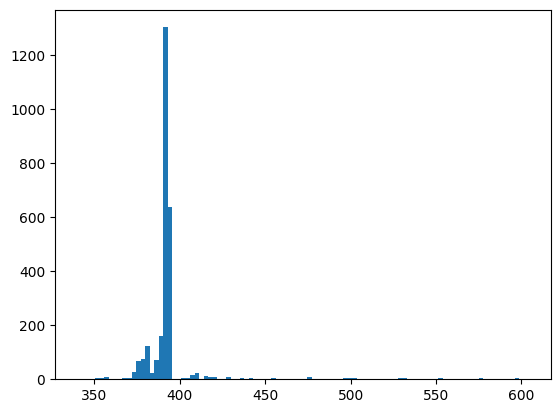

In [ ]:
import matplotlib.pyplot as plt
market_lengths = []
for metadata in market_metadata:
    if (metadata.expiration_ts - metadata.open_ts).total_seconds() / 3600 > 1000:
        pprint(metadata)
    else:
        market_lengths.append((metadata.expiration_ts - metadata.open_ts).total_seconds() / 3600)

